In [ ]:
import numpy as np
from scipy.special import jv # Bessel function of the first kind
# !pip install numba
from numba import jit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 988.3 kB/s eta 0:00:0000:01:020m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


In [3]:
@jit(nopython=True)
def process_bessel_values(bessel_values):
  result = np.empty_like(bessel_values)
  for i in range(bessel_values.size):
    result[i] = bessel_values[i] * 2.0
  return result

n = 0
x = np.linspace(0, 20, 1000)

bessel_values = jv(n, x)

processed_bessel_values = process_bessel_values(bessel_values)
print(processed_bessel_values)

[ 2.00000000e+00  1.99979960e+00  1.99919848e+00  1.99819680e+00
  1.99679488e+00  1.99499312e+00  1.99279208e+00  1.99019242e+00
  1.98719491e+00  1.98380046e+00  1.98001008e+00  1.97582493e+00
  1.97124624e+00  1.96627541e+00  1.96091391e+00  1.95516337e+00
  1.94902550e+00  1.94250216e+00  1.93559529e+00  1.92830698e+00
  1.92063940e+00  1.91259486e+00  1.90417577e+00  1.89538465e+00
  1.88622414e+00  1.87669699e+00  1.86680604e+00  1.85655427e+00
  1.84594473e+00  1.83498061e+00  1.82366518e+00  1.81200184e+00
  1.79999406e+00  1.78764544e+00  1.77495966e+00  1.76194052e+00
  1.74859190e+00  1.73491778e+00  1.72092225e+00  1.70660948e+00
  1.69198372e+00  1.67704934e+00  1.66181079e+00  1.64627260e+00
  1.63043939e+00  1.61431587e+00  1.59790682e+00  1.58121713e+00
  1.56425173e+00  1.54701568e+00  1.52951407e+00  1.51175208e+00
  1.49373498e+00  1.47546810e+00  1.45695684e+00  1.43820666e+00
  1.41922310e+00  1.40001177e+00  1.38057832e+00  1.36092848e+00
  1.34106803e+00  1.32100

In [4]:
import numpy as np
from numba import njit
from scipy.special import jv  # Bessel function of the first kind

# Define the integrand function
def integrand(x, v):
    return x * jv(v, x)

# Define the function to perform numerical integration using the trapezoidal rule
@njit
def integrate_bessel(x, y):
    return np.trapz(y, x)

# Parameters
a = 0
b = 10
n = 1000
v = 0  # Order of the Bessel function

# Generate x values and compute the integrand values
x = np.linspace(a, b, n)
y = integrand(x, v)

# Perform the integration
result = integrate_bessel(x, y)
print("Integral result:", result)

AttributeError: module 'numpy' has no attribute 'trapz'

# Taylor expansion examples

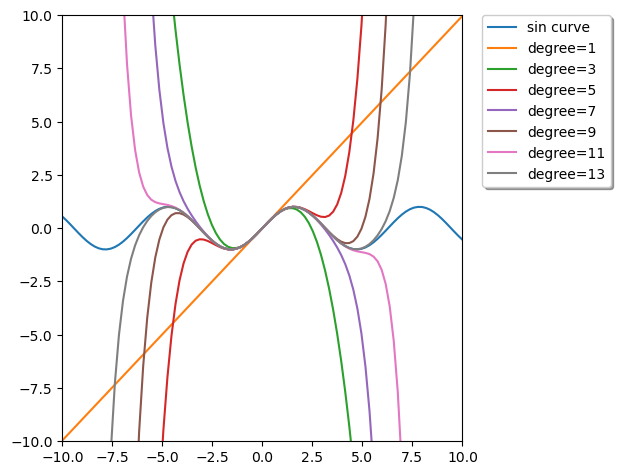

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial
x = np.linspace(-10.0, 10.0, num=100)
plt.plot(x, np.sin(x), label="sin curve")
for degree in np.arange(1, 15, step=2):
    sin_taylor = approximate_taylor_polynomial(np.sin, 0, degree, 1,
                                               order=degree + 2)
    plt.plot(x, sin_taylor(x), label=f"degree={degree}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
           borderaxespad=0.0, shadow=True)
plt.tight_layout()
plt.axis([-10, 10, -10, 10])
plt.show()

In [7]:
taylor = approximate_taylor_polynomial(np.exp, 0, 3, 1, order = 5)
print(taylor(1.0))  # Should be close to np.exp(1.0)

2.665028678081161


In [16]:
from sympy import *

x = symbols('x')
f = cos(x)

# Expand around x = π/2
s = series(f, x, pi/2, n=6)
print("cos(x) around x = π/2:")
print(s)

# Substitute to verify: cos(π/2) should be ≈ 0
print("\nAt x = π/2:", s.removeO().subs(x, pi/2))

cos(x) around x = π/2:
pi/2 + (x - pi/2)**3/6 - (x - pi/2)**5/120 - x + O((x - pi/2)**6, (x, pi/2))

At x = π/2: 0


In [22]:
x = symbols('x')
f = sin(x) * exp(x)

s = series(f, x, 0, n=5)
print(s)

x + x**2 + x**3/3 + O(x**5)


$Ae^{i\phi} = (\frac{r_0}{r_m})^3 \cdot \frac{RJ_{5/2}(r_0k) - J_{-5/2}(r_0k)}{RJ_{1/2}(r_0k) - J_{-1/2}(r_0kc)}$

$R = \frac{r_1kJ_{-5/2}(r_1k)}{3J_{3/2}(r_1k) - r_1kJ_{1/2}(r_1k)}$

$Ae^{i\phi}\approx (\frac{r_0}{r_m})^3 (\frac{r_1}{(r_0 - (\frac{r_0r_1k}{3})tan(k(r_0-r_1)))}-1) + O(\frac{1}{x^2})$

In [50]:
from sympy import symbols, besselj, series, I, exp, oo, latex

In [ ]:
r0, r1, k, rm = symbols('r0 r1 k rm')
R = (r1 * k * besselj(-5/2, r1*k))
R = R / (3 * besselj(3/2, r1*k) - r1 * k * besselj(1/2, r1*k))

Aeio = 1
# Aeio = (r0 / rm)**3
# Aeio = Aeio * (R * besselj(5/2, r0*k) - besselj(-5/2, r0*k)) # num
# Aeio = Aeio / (R * besselj(1/2, r0*k) - besselj(-1/2, r0*k)) # den
Aeio = 1/r0**3 * sin(r0*k)

# s = series(Aeio, 1/(r0*k), 0, n=2)
s = series(Aeio, (r0*k), 0, n=2)
# print(s)
# s = simplify(s)
print(latex(s), "\n")
print(s)


NotImplementedError: 

In [ ]:
r0, r1, k, rm = symbols('r0 r1 k rm')
x = symbols('x')
R = (r1 * k * besselj(-5/2, r1*k))
R = R / (3 * besselj(3/2, r1*k) - r1 * k * besselj(1/2, r1*k))

Aeio = 1
# Aeio = (r0 / rm)**3
# Aeio = Aeio * (R * besselj(5/2, r0*k) - besselj(-5/2, r0*k)) # num
# Aeio = Aeio / (R * besselj(1/2, r0*k) - besselj(-1/2, r0*k)) # den
# Aeio = 1/x * exp(x)
# Aeio = besselj(5/2, x)

Aeio = (r0 / rm)**3
Aeio = Aeio * (R * besselj(5/2, r0*k) - besselj(-5/2, r0*k)) # num
Aeio = Aeio / (R * besselj(1/2, r0*k) - besselj(-1/2, r0*k)) # den

# num = besselj(2.5, r0) - besselj(-2.5, r0)
# den = besselj(1.5, r0) - besselj(-1.5, r0)
# result = num / den


s = series(Aeio, r0, 0.1, n=2)
# print(s)
s = simplify(s)
# print(latex(s))
print(s)



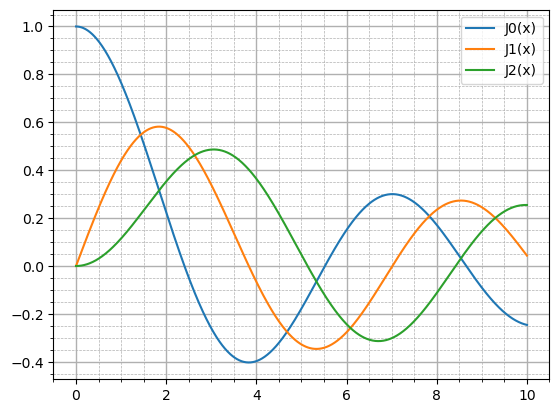

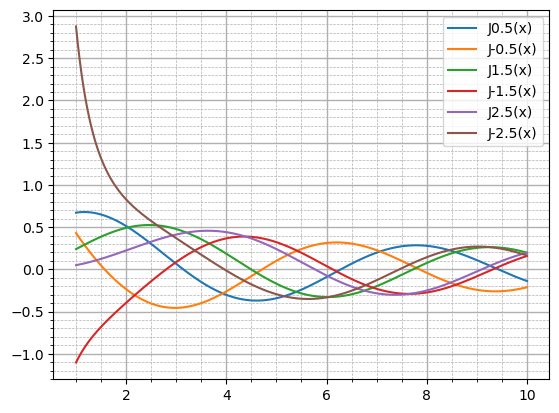

In [106]:
x = np.linspace(0, 10, 1000)
y1 = jv(0, x)  # Bessel function of the first kind, order 0
y2 = jv(1, x)
y3 = jv(2, x)

plt.plot(x, y1, label="J0(x)")
plt.plot(x, y2, label="J1(x)")
plt.plot(x, y3, label="J2(x)")
plt.legend()
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.show()

x = np.linspace(1, 10, 1000)
y4 = jv(0.5, x)
y5 = jv(-0.5, x)
y6 = jv(1.5, x)
y7 = jv(-1.5, x)
y8 = jv(2.5, x)
y9 = jv(-2.5, x)

plt.plot(x, y4, label="J0.5(x)")
plt.plot(x, y5, label="J-0.5(x)")
plt.plot(x, y6, label="J1.5(x)")
plt.plot(x, y7, label="J-1.5(x)")
plt.plot(x, y8, label="J2.5(x)")
plt.plot(x, y9, label="J-2.5(x)")
plt.legend()
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.show()

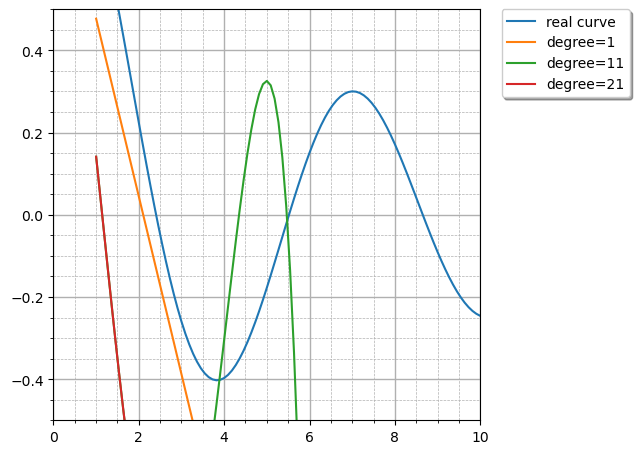

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial
x = np.linspace(1, 10.0, num=100)
# f = besselj(0, x)
# f = jv(0, x)
f = np.sin

plt.plot(x, jv(0, x), label="real curve")
for degree in np.arange(1, 30, step=10):
    curve_taylor = approximate_taylor_polynomial(f, 2, degree, 1,
                                               order=degree + 2)
    plt.plot(x, curve_taylor(x), label=f"degree={degree}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
           borderaxespad=0.0, shadow=True)
plt.tight_layout()
plt.axis([0, 10, -0.5, 0.5])
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.show()

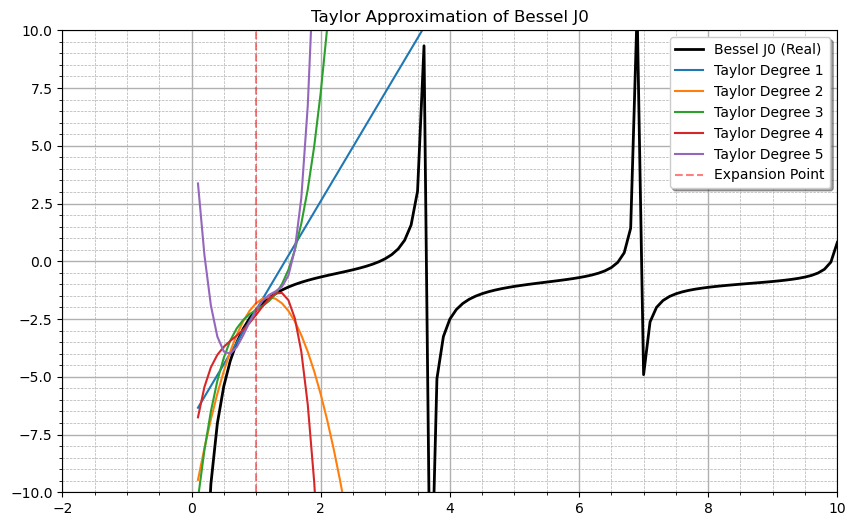

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv  # Correct import for numerical Bessel
from sympy import *
from scipy.interpolate import approximate_taylor_polynomial

# 1. Define the x-range
x = np.linspace(0.1, 10.0, num=100)

# 2. Define the function wrapper
# approximate_taylor_polynomial needs a function it can call as f(x)
def bessel_func(z):
    # return jv(1, z)
    # return np.sin(z)
    # return x**3 + x**2 + x + 1
    # return jv(5/2, z)

    num = jv(2.5, z) - jv(-2.5, z)
    den = jv(1.5, z) - jv(-1.5, z)
    result = num / den


    return result


# r0, r1, k, rm = symbols('r0 r1 k rm')
# x = symbols('x')
# R = (r1 * k * besselj(-5/2, r1*k))
# R = R / (3 * besselj(3/2, r1*k) - r1 * k * besselj(1/2, r1*k))

# Aeio = 1
# Aeio = (r0 / rm)**3
# Aeio = Aeio * (R * besselj(5/2, r0*k) - besselj(-5/2, r0*k)) # num
# Aeio = Aeio / (R * besselj(1/2, r0*k) - besselj(-1/2, r0*k)) # den

# s = series(Aeio, x, 0, n=2)
# print(s)
# s = simplify(s)
# print(latex(s))
# print(s)

plt.figure(figsize=(10, 6))
plt.plot(x, bessel_func(x), 'k', lw=2, label="Bessel J0 (Real)")

x0 = 1

for degree in [1, 2, 3, 4, 5]:
    curve_taylor = approximate_taylor_polynomial(bessel_func, x0, degree, scale=1.0, order=degree+2)

    plt.plot(x, curve_taylor(x-x0), label=f"Taylor Degree {degree}")

plt.axvline(x0, color='r', linestyle='--', alpha=0.5, label="Expansion Point")
plt.legend(loc='best', shadow=True)
# plt.axis([-2, 8, -300, 300]) # Adjusted axis to see J0 clearly
plt.axis([-2, 10, -10.0, 10.0]) # Adjusted axis to see J0 clearly
# plt.axis([-1, 8, -0.4, 0.5])
plt.title("Taylor Approximation of Bessel J0")
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth=0.5)
plt.grid(which='major', linestyle='-', linewidth=1)
plt.savefig("bessel_taylor_approximation.png", dpi=300, bbox_inches='tight')
plt.show()

$\frac{k r_{1} J_{-2.5}\left(k r_{1}\right) J_{2.5}\left(k r_{0}\right) + \left(k r_{1} J_{0.5}\left(k r_{1}\right) - 3 J_{1.5}\left(k r_{1}\right)\right) J_{-2.5}\left(k r_{0}\right)}{k r_{1} J_{-2.5}\left(k r_{1}\right) J_{0.5}\left(k r_{0}\right) + \left(k r_{1} J_{0.5}\left(k r_{1}\right) - 3 J_{1.5}\left(k r_{1}\right)\right) J_{-0.5}\left(k r_{0}\right)}$

$\frac{\frac{k r_{1} J_{-2.5}\left(k r_{1}\right) J_{2.5}\left(k r_{0}\right)}{- k r_{1} J_{0.5}\left(k r_{1}\right) + 3 J_{1.5}\left(k r_{1}\right)} - J_{-2.5}\left(k r_{0}\right)}{\frac{k r_{1} J_{-2.5}\left(k r_{1}\right) J_{0.5}\left(k r_{0}\right)}{- k r_{1} J_{0.5}\left(k r_{1}\right) + 3 J_{1.5}\left(k r_{1}\right)} - J_{-0.5}\left(k r_{0}\right)}$

The result is `{python} f"{s}"`

In [ ]:
import sympy as sp

def prove_chyba_approximation():
    # Define variables: x0 = k*r0, x1 = k*r1
    x0, x1 = sp.symbols('x0 x1', real=True)

    # 1. Exact Trigonometric Definitions
    # (We ignore the common sqrt(2/(pi*x)) factor as it cancels out in fractions)
    J_1_2_x0  = sp.sin(x0)
    J_m1_2_x0 = sp.cos(x0)
    J_3_2_x1  = sp.sin(x1)/x1 - sp.cos(x1)

    # 2. Applying the Large-x Approximation O(1/x^2) -> 0
    # The paper discards the 3/x^2 terms for J_5/2 and J_-5/2
    J_5_2_x0  = -sp.sin(x0) - (3/x0)*sp.cos(x0)
    J_m5_2_x0 = (3/x0)*sp.sin(x0) - sp.cos(x0)
    J_m5_2_x1 = (3/x1)*sp.sin(x1) - sp.cos(x1)

    # 3. Construct the 'R' parameter (Ocean floor boundary)
    # R_denominator = 3*J_3/2(x1) - x1*J_1/2(x1)
    # The paper also drops 3*sin(x1)/x1 as it is ~0 compared to x1*sin(x1)
    R_num = x1 * J_m5_2_x1
    R_den = -3 * sp.cos(x1) - x1 * sp.sin(x1)
    R = R_num / R_den

    # 4. Construct the Amplitude Fraction
    # A_fraction = (R * J_5/2 - J_-5/2) / (R * J_1/2 - J_-1/2)
    Num = R * J_5_2_x0 - J_m5_2_x0
    Den = R * J_1_2_x0 - J_m1_2_x0
    Amplitude_Fraction = Num / Den

    # 5. Let SymPy simplify the massive fraction using Trig Identities
    print("Simplifying fraction... (this may take a second)")
    simplified_fraction = sp.trigsimp(Amplitude_Fraction)

    # 6. Substitute (x0 - x1) with a single symbol 'Delta' to make it readable
    Delta = sp.symbols('Delta')
    fraction_grouped = simplified_fraction.subs(x0 - x1, Delta)

    # We expand the fraction to clearly see the cos(Delta) and sin(Delta) terms
    final_output = sp.expand(fraction_grouped)

    print("\nSymPy Collapsed Fraction")
    sp.pprint(final_output)

if __name__ == "__main__":
    prove_chyba_approximation()

Simplifying fraction... (this may take a second)

=== SymPy Collapsed Fraction ===
         3⋅x₁⋅cos(Δ)                x₁⋅sin(Δ)                  9⋅sin(Δ)        ↪
- ────────────────────────── - ──────────────────── - ──────────────────────── ↪
  x₀⋅x₁⋅sin(Δ) - 3⋅x₀⋅cos(Δ)   x₁⋅sin(Δ) - 3⋅cos(Δ)   x₀⋅x₁⋅sin(Δ) - 3⋅x₀⋅cos( ↪

↪            3⋅cos(Δ)      
↪ ── + ────────────────────
↪ Δ)   x₁⋅sin(Δ) - 3⋅cos(Δ)
